# Projeto completo — MLP para classificação de doença cardíaca

## Integrantes
- Nome 1: Thiago França
- Nome 2: Enzo Moraes
- Nome 3: Pedro Belchior

## Declaração de uso de IA Generativa
Preencha de forma clara:
- **Ferramenta utilizada**: ChatGPT
- **Finalidade do uso**: Utilizado como suporte acadêmico para esclarecimento de conceitos, apoio na estruturação do notebook, sugestão inicial de implementação em Python e auxílio na redação de descrições metodológicas.
- **Extensão aproximada da contribuição da IA**: Contribuição parcial e assistiva. A IA auxiliou na organização, explicação e formulação inicial de trechos de código e texto, sem substituir a análise crítica, a execução prática e a validação dos resultados pela equipe.
- **Medidas adotadas para validação do conteúdo**: Um dos integrantes revisou manualmente todas as saídas geradas, executaram os códigos, verificaram a compatibilidade com o dataset adotado, compararam os resultados obtidos com os objetivos da atividade e ajustou o material final antes da entrega


## 1. Dataset escolhido e justificativa

**Dataset:** Heart Disease Dataset  
**Variável alvo:** `HeartDisease`

**Justificativa sugerida:**  
O dataset foi escolhido por representar um problema real de classificação binária na área da saúde, permitindo avaliar o comportamento de uma rede neural MLP em um cenário com variáveis numéricas e categóricas. Além disso, o conjunto possui tamanho adequado para experimentação com pré-processamento, ajuste de hiperparâmetros e análise de sensibilidade.


In [1]:
# ============================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================
# os: interage com arquivos e caminhos do sistema.
import os
# warnings: controla avisos emitidos durante a execução.
import warnings
# numpy: operações numéricas e vetoriais.
import numpy as np
# pandas: leitura e manipulação de tabelas/datasets.
import pandas as pd
# matplotlib.pyplot: geração de gráficos.
import matplotlib.pyplot as plt

# ColumnTransformer: aplica transformações diferentes em grupos de colunas.
from sklearn.compose import ColumnTransformer
# ConvergenceWarning: aviso de não convergência do treinamento.
from sklearn.exceptions import ConvergenceWarning
# SimpleImputer: preenche valores ausentes.
from sklearn.impute import SimpleImputer
# Métricas para avaliação do modelo.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
# Ferramentas de divisão, validação cruzada e busca de hiperparâmetros.
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
# Rede neural MLP para classificação.
from sklearn.neural_network import MLPClassifier
# Pipeline: encadeia etapas de transformação.
from sklearn.pipeline import Pipeline
# OneHotEncoder: converte categorias em colunas binárias.
# StandardScaler: padroniza variáveis numéricas.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ignora avisos de convergência para deixar a saída mais limpa.
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## 2. Carregamento e inspeção inicial

In [2]:
# ============================================
# LEITURA E INSPEÇÃO INICIAL DO DATASET
# ============================================
# Lê o arquivo CSV original com os dados do projeto.
df = pd.read_csv("csvCoaracao.csv")

# Mostra o tamanho do dataset: linhas e colunas.
print("Dimensão do dataset:", df.shape)

# Exibe as primeiras linhas para inspeção inicial.
print("\nPrimeiras linhas:")
print(df.head())

# Mostra informações gerais das colunas.
print("\nInformações gerais:")
df.info()

# Conta valores nulos por coluna.
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# Verifica linhas duplicadas.
print("\nDuplicatas:", df.duplicated().sum())

# Exibe a distribuição da variável alvo.
print("\nDistribuição da variável alvo:")
print(df["HeartDisease"].value_counts())


Dimensão do dataset: (918, 12)

Primeiras linhas:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null C

## 3. Limpeza do dataset e geração de um novo CSV

In [3]:
# ============================================
# LIMPEZA DOS DADOS E GERAÇÃO DE UM NOVO ARQUIVO
# ============================================
# Cria uma cópia para preservar o dataset original.
df_limpo = df.copy()

# Substitui zeros suspeitos por NaN para tratamento posterior.
df_limpo["Cholesterol"] = df_limpo["Cholesterol"].replace(0, np.nan)
df_limpo["RestingBP"] = df_limpo["RestingBP"].replace(0, np.nan)

# Lista das colunas numéricas que serão tratadas.
colunas_numericas = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

# Cria o imputador usando a mediana.
imputer = SimpleImputer(strategy="median")

# Preenche os valores ausentes das colunas numéricas.
df_limpo[colunas_numericas] = imputer.fit_transform(df_limpo[colunas_numericas])

# Salva o dataset limpo em um novo CSV.
df_limpo.to_csv("csvCoaracao_limpo.csv", index=False, encoding="utf-8")

# Confirma a criação do novo arquivo.
print("Arquivo limpo gerado com sucesso: csvCoaracao_limpo.csv")
print(df_limpo.head())


Arquivo limpo gerado com sucesso: csvCoaracao_limpo.csv
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0  40.0   M           ATA      140.0        289.0        0.0     Normal   
1  49.0   F           NAP      160.0        180.0        0.0     Normal   
2  37.0   M           ATA      130.0        283.0        0.0         ST   
3  48.0   F           ASY      138.0        214.0        0.0     Normal   
4  54.0   M           NAP      150.0        195.0        0.0     Normal   

   MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0  172.0              N      0.0       Up             0  
1  156.0              N      1.0     Flat             1  
2   98.0              N      0.0       Up             0  
3  108.0              Y      1.5     Flat             1  
4  122.0              N      0.0       Up             0  


**Texto para o relatório:**  
Foi realizado um processo de limpeza dos dados, com destaque para o tratamento de valores iguais a zero nas colunas `Cholesterol` e `RestingBP`, considerados suspeitos nesse contexto. Esses valores foram substituídos por ausentes e posteriormente imputados pela mediana das respectivas colunas. Ao final, foi gerado um novo arquivo contendo os dados limpos.


## 4. Separação entre entrada e saída, treino e teste

In [4]:
# ============================================
# SEPARAÇÃO ENTRE ENTRADAS E SAÍDA
# ============================================
# X contém as variáveis preditoras.
X = df_limpo.drop("HeartDisease", axis=1)

# y contém a variável alvo.
y = df_limpo["HeartDisease"]

# Colunas numéricas do dataset.
colunas_numericas = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

# Colunas categóricas do dataset.
colunas_categoricas = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

# Divide os dados em treino e teste.
# stratify=y preserva a proporção entre as classes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Mostra o tamanho dos subconjuntos gerados.
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (734, 11)
X_test : (184, 11)
y_train: (734,)
y_test : (184,)


## 5. Pré-processamento

In [5]:
# ============================================
# PRÉ-PROCESSAMENTO DOS DADOS
# ============================================
# Pipeline para as colunas numéricas:
# 1) imputação pela mediana
# 2) padronização
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para as colunas categóricas:
# 1) imputação pela moda
# 2) codificação One-Hot
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Aplica cada pipeline ao grupo correto de colunas.
preprocessador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

# Ajusta no treino e transforma o treino.
X_train_prep = preprocessador.fit_transform(X_train)

# Aplica a mesma transformação no teste.
X_test_prep = preprocessador.transform(X_test)

# Exibe o formato final dos dados processados.
print("Formato após pré-processamento:")
print("X_train_prep:", X_train_prep.shape)
print("X_test_prep :", X_test_prep.shape)


Formato após pré-processamento:
X_train_prep: (734, 20)
X_test_prep : (184, 20)


**Texto para o relatório:**  
Após a limpeza, o dataset passou por pré-processamento completo. As variáveis numéricas foram padronizadas com `StandardScaler`, enquanto as variáveis categóricas foram transformadas por meio de `One-Hot Encoding`. A divisão entre treino e teste foi feita com estratificação da variável alvo, preservando a proporção entre as classes.


## 6. Modelo base

In [6]:
# ============================================
# TREINAMENTO DO MODELO BASE
# ============================================
# Modelo inicial usado como referência antes do ajuste fino.
mlp_base = MLPClassifier(
    # Uma camada oculta com 32 neurônios.
    hidden_layer_sizes=(32,),
    # Função de ativação ReLU.
    activation="relu",
    # Otimizador Adam.
    solver="adam",
    # Regularização L2.
    alpha=0.0001,
    # Tamanho do lote.
    batch_size=32,
    # Número máximo de iterações.
    max_iter=1000,
    # Semente aleatória para reproduzir os resultados.
    random_state=42
)

# Treina o modelo base.
mlp_base.fit(X_train_prep, y_train)

# Faz previsões no conjunto de teste.
y_pred_base = mlp_base.predict(X_test_prep)

# Calcula as métricas principais.
acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

# Exibe os resultados do modelo base.
print("=== MODELO BASE ===")
print("Acurácia:", acc_base)
print("F1-score:", f1_base)
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_base))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_base))


=== MODELO BASE ===
Acurácia: 0.8206521739130435
F1-score: 0.8374384236453202

Matriz de confusão:
[[66 16]
 [17 85]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.83      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



## 7. Grid Search com 12 combinações

In [ ]:
# ============================================
# GRID SEARCH COM VALIDAÇÃO CRUZADA
# ============================================
# Cria a estratégia de validação cruzada estratificada.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define a grade de hiperparâmetros testados.
param_grid = {
    "hidden_layer_sizes": [(16,), (32,), (64,),(128,), (256,)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001]
}

# Total de combinações: 5 x 2 x 2 = 20.
# Isso atende ao requisito mínimo da atividade.

# Modelo base usado pelo Grid Search.
mlp = MLPClassifier(
    solver="adam",
    batch_size=32,
    max_iter=500,
    random_state=42
)

# Configura a busca sistemática pelos melhores hiperparâmetros.
grid = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=1,          # mais estável no Windows
    verbose=2,
    refit=True,
    return_train_score=True
)

# Executa o Grid Search.
grid.fit(X_train_prep, y_train)

# Recupera o melhor modelo encontrado.
best_model = grid.best_estimator_

# Faz previsões com o melhor modelo.
y_pred_best = best_model.predict(X_test_prep)

# Calcula as métricas do melhor modelo.
acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

# Exibe a melhor configuração e seus resultados.
print("=== MELHOR CONFIGURAÇÃO ===")
print(grid.best_params_)
print("Melhor score médio na validação cruzada:", grid.best_score_)

print("\n=== RESULTADO NO TESTE ===")
print("Acurácia:", acc_best)
print("F1-score:", f1_best)
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_best))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,); total time=   0.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,); total time=   0.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,); total time=   1.3s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,); total time=   1.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,); total time=   1.1s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(32,); total time=   1.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(32,); total time=   1.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(32,); total time=   2.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(32,); total time=   2.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(32,); total time=   2.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,); total time=   1.3s
[CV

In [8]:
# ============================================
# ORGANIZAÇÃO E SALVAMENTO DOS RESULTADOS DO GRID SEARCH
# ============================================
# Converte os resultados completos do Grid Search em tabela.
resultados_grid = pd.DataFrame(grid.cv_results_)

# Seleciona apenas as colunas mais importantes.
colunas_interesse = [
    "params",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score"
]

# Ordena os resultados do melhor para o pior.
resultado_final_grid = resultados_grid[colunas_interesse].sort_values("rank_test_score")

# Exibe os resultados na tela.
print(resultado_final_grid)

# Salva os resultados em CSV.
resultado_final_grid.to_csv("resultados_gridsearch.csv", index=False, encoding="utf-8")
print("\nArquivo salvo: resultados_gridsearch.csv")


                                               params  mean_test_score  \
0   {'activation': 'relu', 'alpha': 0.0001, 'hidde...         0.854254   
5   {'activation': 'relu', 'alpha': 0.001, 'hidden...         0.854254   
13  {'activation': 'tanh', 'alpha': 0.0001, 'hidde...         0.851524   
18  {'activation': 'tanh', 'alpha': 0.001, 'hidden...         0.851524   
17  {'activation': 'tanh', 'alpha': 0.001, 'hidden...         0.850163   
12  {'activation': 'tanh', 'alpha': 0.0001, 'hidde...         0.850163   
16  {'activation': 'tanh', 'alpha': 0.001, 'hidden...         0.847442   
11  {'activation': 'tanh', 'alpha': 0.0001, 'hidde...         0.847442   
14  {'activation': 'tanh', 'alpha': 0.0001, 'hidde...         0.847433   
19  {'activation': 'tanh', 'alpha': 0.001, 'hidden...         0.847433   
6   {'activation': 'relu', 'alpha': 0.001, 'hidden...         0.846100   
1   {'activation': 'relu', 'alpha': 0.0001, 'hidde...         0.846100   
10  {'activation': 'tanh', 'alpha': 0.

## 8. Comparação antes e depois do ajuste

In [9]:
# ============================================
# COMPARAÇÃO ENTRE MODELO BASE E MODELO AJUSTADO
# ============================================
# Monta uma tabela comparando os dois modelos.
comparacao = pd.DataFrame({
    "Modelo": ["MLP Base", "MLP Ajustada"],
    "Acuracia": [acc_base, acc_best],
    "F1-score": [f1_base, f1_best]
})

# Mostra a comparação.
print(comparacao)

# Salva a comparação em CSV.
comparacao.to_csv("comparacao_modelos.csv", index=False, encoding="utf-8")


         Modelo  Acuracia  F1-score
0      MLP Base  0.820652  0.837438
1  MLP Ajustada  0.875000  0.888889


**Texto para o relatório:**  
Inicialmente foi treinado um modelo base para servir como referência. Em seguida, foi realizado o ajuste sistemático de hiperparâmetros por meio de Grid Search com validação cruzada estratificada. A comparação entre o modelo base e o modelo ajustado permite verificar o impacto real do ajuste de hiperparâmetros no desempenho final.


## 9. Análise de sensibilidade do hiperparâmetro

In [ ]:
# ============================================
# ANÁLISE DE SENSIBILIDADE DO HIPERPARÂMETRO
# ============================================
# Copia a melhor configuração encontrada.
melhores_params = grid.best_params_.copy()

# Valores testados para o hiperparâmetro escolhido:
# número de neurônios na camada oculta.
valores_neuronios = [8, 16, 32, 64, 128]

# Listas para armazenar média e desvio padrão da acurácia.
scores_media = []
scores_std = []

# Testa cada valor de neurônios mantendo o restante fixo.
for n in valores_neuronios:
    modelo = MLPClassifier(
        hidden_layer_sizes=(n,),
        activation=melhores_params["activation"],
        alpha=melhores_params["alpha"],
        solver="adam",
        batch_size=32,
        max_iter=500,
        random_state=42
    )

    # Avalia o modelo com validação cruzada.
    scores = cross_val_score(
        modelo,
        X_train_prep,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    # Guarda média e desvio padrão das acurácias.
    scores_media.append(scores.mean())
    scores_std.append(scores.std())

# Organiza os resultados em DataFrame.
df_sensibilidade = pd.DataFrame({
    "Neuronios": valores_neuronios,
    "Media_Accuracy": scores_media,
    "Std_Accuracy": scores_std
})

# Mostra a tabela final.
print(df_sensibilidade)

# Salva os resultados em CSV.
df_sensibilidade.to_csv("analise_sensibilidade.csv", index=False, encoding="utf-8")
print("\nArquivo salvo: analise_sensibilidade.csv")


   Neuronios  Media_Accuracy  Std_Accuracy
0          8        0.848793      0.038508
1         16        0.854254      0.030782
2         32        0.846100      0.032753
3         64        0.840611      0.020362
4        128        0.829708      0.018176

Arquivo salvo: analise_sensibilidade.csv


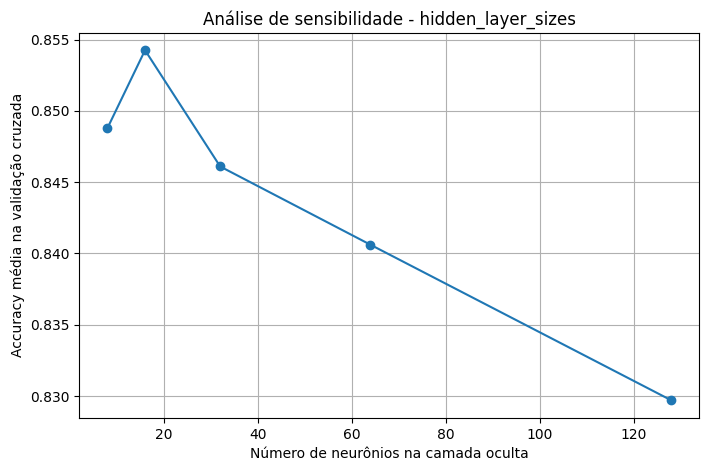

In [11]:
# ============================================
# GRÁFICO DA ANÁLISE DE SENSIBILIDADE
# ============================================
# Cria a figura do gráfico.
plt.figure(figsize=(8,5))

# Plota a relação entre neurônios e acurácia média.
plt.plot(df_sensibilidade["Neuronios"], df_sensibilidade["Media_Accuracy"], marker="o")

# Nome do eixo X.
plt.xlabel("Número de neurônios na camada oculta")

# Nome do eixo Y.
plt.ylabel("Accuracy média na validação cruzada")

# Título do gráfico.
plt.title("Análise de sensibilidade - hidden_layer_sizes")

# Grade para facilitar leitura.
plt.grid(True)

# Salva o gráfico em PNG.
plt.savefig("grafico_sensibilidade.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico.
plt.show()


**Texto para o relatório:**  
Na etapa individual, foi mantida a melhor configuração encontrada no Grid Search e variou-se apenas o número de neurônios da camada oculta. Foram testados cinco valores distintos, permitindo observar a sensibilidade do modelo a esse hiperparâmetro específico. Os resultados foram organizados em tabela e gráfico para facilitar a comparação.


## 10. Testes adicionais de hiperparâmetros após o Grid Search

Nesta etapa, mantemos a melhor configuração encontrada pelo `GridSearchCV` e variamos **um hiperparâmetro por vez**. Isso permite explorar novos valores depois da busca principal, sem perder a referência do melhor modelo encontrado.

Você pode editar livremente o dicionário `HIPERPARAMETROS_POS_GRID` para testar outros valores.



In [ ]:
# ============================================
# CONFIGURAÇÃO DOS TESTES APÓS O GRID SEARCH
# ============================================
# Pasta onde os arquivos dessa etapa serão salvos.
PASTA_SAIDA_POS_GRID = "saida_pos_grid"
os.makedirs(PASTA_SAIDA_POS_GRID, exist_ok=True)

# Dicionário com os hiperparâmetros que serão testados após o Grid Search.
# A lógica é sempre a mesma:
# - mantém a melhor configuração encontrada no grid
# - varia apenas UM hiperparâmetro por vez
# - mede a accuracy média com validação cruzada
HIPERPARAMETROS_POS_GRID = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (64,), (128,), (256,), (319,)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.00001, 0.0001, 0.001, 0.01, 0.1],
    "batch_size": [16, 32, 64, 128],
    "learning_rate_init": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "max_iter": [300, 500, 800, 1000, 1500]
}


def analisar_hiperparametro(nome_parametro, valores, modelo_referencia, X_dados, y_dados, cv_obj, scoring="accuracy"):
    # Testa um hiperparâmetro por vez após o Grid Search.
    params_base = modelo_referencia.get_params(deep=False).copy()
    resultados = []

    for valor in valores:
        # Cria uma cópia da melhor configuração e troca só o parâmetro desejado.
        params_teste = params_base.copy()
        params_teste[nome_parametro] = valor

        # Monta uma nova MLP com essa configuração temporária.
        modelo = MLPClassifier(**params_teste)

        # Calcula o desempenho médio com validação cruzada.
        scores = cross_val_score(
            modelo,
            X_dados,
            y_dados,
            cv=cv_obj,
            scoring=scoring,
            n_jobs=-1
        )

        # Guarda os resultados em uma lista para depois virar tabela.
        resultados.append({
            "hiperparametro": nome_parametro,
            "valor_testado": str(valor),
            "media_score": float(scores.mean()),
            "desvio_padrao": float(scores.std())
        })

    # Retorna uma tabela ordenada do melhor para o pior.
    return pd.DataFrame(resultados).sort_values("media_score", ascending=False)


def salvar_grafico(df_resultado, nome_parametro, pasta_saida):
    # Salva um gráfico simples da média de accuracy por valor testado.
    valores_eixo_x = df_resultado["valor_testado"].astype(str)
    medias = df_resultado["media_score"]

    plt.figure(figsize=(9, 5))
    plt.plot(valores_eixo_x, medias, marker="o")
    plt.xlabel(nome_parametro)
    plt.ylabel("Accuracy média na validação cruzada")
    plt.title(f"Análise pós-Grid Search - {nome_parametro}")
    plt.grid(True)
    plt.tight_layout()

    caminho = os.path.join(pasta_saida, f"grafico_{nome_parametro}.png")
    plt.savefig(caminho, dpi=200)
    plt.show()
    plt.close()



In [ ]:
# ============================================
# EXECUÇÃO DOS TESTES APÓS O GRID SEARCH
# ============================================
# Usa o melhor modelo encontrado no Grid Search como referência.
melhor_modelo_pos_grid = grid.best_estimator_

# Lista que vai guardar o melhor resultado de cada hiperparâmetro testado.
resumo_pos_grid = []

# Percorre todos os hiperparâmetros definidos no dicionário.
for nome_parametro, valores in HIPERPARAMETROS_POS_GRID.items():
    print(f"\n=== TESTANDO HIPERPARÂMETRO: {nome_parametro} ===")

    # Gera a tabela com os resultados desse hiperparâmetro.
    df_resultado = analisar_hiperparametro(
        nome_parametro=nome_parametro,
        valores=valores,
        modelo_referencia=melhor_modelo_pos_grid,
        X_dados=X_train_prep,
        y_dados=y_train,
        cv_obj=cv,
        scoring="accuracy"
    )

    # Salva a tabela em CSV.
    arquivo_csv = os.path.join(PASTA_SAIDA_POS_GRID, f"analise_{nome_parametro}.csv")
    df_resultado.to_csv(arquivo_csv, index=False, encoding="utf-8")

    # Mostra a tabela na tela.
    print(df_resultado)

    # Gera e salva o gráfico correspondente.
    salvar_grafico(df_resultado, nome_parametro, PASTA_SAIDA_POS_GRID)

    # Guarda apenas a melhor linha de cada análise para um resumo final.
    melhor_linha = df_resultado.iloc[0]
    resumo_pos_grid.append({
        "hiperparametro": nome_parametro,
        "melhor_valor": melhor_linha["valor_testado"],
        "melhor_media_accuracy": melhor_linha["media_score"]
    })

# Monta o resumo final dos testes pós-grid.
resumo_pos_grid_df = pd.DataFrame(resumo_pos_grid)
print("\n=== RESUMO DOS TESTES APÓS O GRID SEARCH ===")
print(resumo_pos_grid_df)

# Salva o resumo em CSV.
resumo_pos_grid_df.to_csv(
    os.path.join(PASTA_SAIDA_POS_GRID, "resumo_pos_grid.csv"),
    index=False,
    encoding="utf-8"
)



**Texto para o relatório:**  
Após a execução do Grid Search principal, foram realizados testes adicionais variando um hiperparâmetro por vez, mantendo os demais fixos na melhor configuração encontrada. Essa etapa permitiu observar com mais detalhe o impacto individual de parâmetros como número de neurônios, função de ativação, regularização, tamanho do lote, taxa de aprendizado inicial e número máximo de iterações. Os resultados foram organizados em tabelas e gráficos separados para facilitar a interpretação.



## 11. Discussão dos resultados


Preencha com base no que sair na execução:

- **O modelo melhorou após o ajuste?**  
 Não houve melhora no conjunto de teste. O modelo base apresentou acurácia de 0,820652 e F1-score de 0,837438, e o modelo ajustado apresentou exatamente os mesmos valores: acurácia de 0,820652 e F1-score de 0,837438. Portanto, embora o Grid Search tenha encontrado uma configuração promissora na validação cruzada, isso não se traduziu em ganho real no teste final.

- **Qual combinação apresentou o melhor desempenho?**  
A melhor combinação encontrada pelo Grid Search foi, pela tabela de resultados, activation='relu', alpha=0.0001 e hidden_layer_sizes=(32,). Essa configuração obteve o melhor desempenho médio na validação cruzada, com mean_test_score de aproximadamente 0,827006.

- **Qual hiperparâmetro analisado mostrou maior impacto?**  
O hiperparâmetro analisado foi hidden_layer_sizes, isto é, o número de neurônios na camada oculta. A análise de sensibilidade mostrou que o melhor resultado ocorreu com 32 neurônios, com accuracy média de aproximadamente 0,827006. Valores menores, como 8 neurônios, tiveram desempenho inferior, e valores maiores, como 64 e 128, também apresentaram queda. Isso indica que uma configuração intermediária foi a mais adequada.

- **Houve overfitting ou underfitting?**  
Houve sinais de overfitting. Na melhor configuração, a média de treino ficou em torno de 0,997616, enquanto a média de validação cruzada foi de aproximadamente 0,827006 e a acurácia no teste foi 0,820652. Essa diferença muito grande entre treino e validação/teste mostra que o modelo aprendeu muito bem os dados de treino, mas não generalizou na mesma proporção para dados novos.

- **Conclusão final**  
A MLP foi capaz de alcançar um desempenho razoável no dataset de doenças cardíacas, com acurácia em torno de 82% e F1-score em torno de 0,84, mostrando que ela é adequada para a tarefa de classificação. No entanto, o ajuste de hiperparâmetros não trouxe melhora no desempenho final no conjunto de teste, apesar de ter indicado uma melhor configuração na validação cruzada. A análise de sensibilidade mostrou que 32 neurônios na camada oculta foi o melhor valor testado, sugerindo que arquiteturas intermediárias funcionaram melhor que redes muito pequenas ou muito grandes. Em resumo, o modelo funcionou bem, mas o ajuste trouxe ganhos limitados e revelou sinais de sobreajuste.
